# Análise Exploratória — Olist E-Commerce

Este notebook responde às perguntas de negócio definidas no projeto a partir
dos dados processados pelo pipeline ETL (`02_tratamento.ipynb`).

**Perguntas respondidas:**
1. Qual estado tem mais pedidos?
2. Qual categoria de produto é mais vendida?
3. Qual período do ano tem mais pedidos?
4. Qual forma de pagamento é mais usada?
5. Qual é o ticket médio geral e por estado?
6. O tempo de entrega impacta a avaliação do cliente?

> **Pré-requisito:** Executar `02_tratamento.ipynb` para gerar os arquivos Parquet em `data/processed/`.

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 1. Carregamento dos dados processados

Os dados utilizados neste notebook já foram tratados e modelados pelo ETL.

- `f_orders`: todos os pedidos com métricas de entrega, avaliação e estado do cliente
- `f_order_items`: itens vendidos com preço, categoria e estado do vendedor
- `f_payments`: transações de pagamento com método e valor

In [28]:
f_orders      = pd.read_parquet('../data/processed/f_orders.parquet')
f_order_items = pd.read_parquet('../data/processed/f_order_items.parquet')
f_payments    = pd.read_parquet('../data/processed/f_payments.parquet')
d_state       = pd.read_parquet('../data/processed/d_state.parquet')
d_category    = pd.read_parquet('../data/processed/d_category.parquet')

print(f"f_orders:      {len(f_orders):,} pedidos")
print(f"f_order_items: {len(f_order_items):,} itens")
print(f"f_payments:    {len(f_payments):,} transações")

f_orders:      99,441 pedidos
f_order_items: 112,650 itens
f_payments:    103,886 transações


## 2. Funções auxiliares de análise

Funções reutilizáveis para agrupamento por contagem e por média,
evitando repetição de código nas análises abaixo.

In [29]:
def calcular_contagem_agrupada(dataframe, coluna_agrupada, coluna_contagem, nome_resultado, qnt_linhas=None):
    """Agrupa por coluna_agrupada e conta ocorrências de coluna_contagem."""
    analise = (
        dataframe.groupby(coluna_agrupada)[coluna_contagem]
        .count()
        .reset_index(name=nome_resultado)
        .sort_values(by=nome_resultado, ascending=False)
    )
    if qnt_linhas is not None:
        analise = analise.head(qnt_linhas)
    return analise

In [30]:
def calcular_media_agrupada(dataframe, coluna_agrupada, coluna_media, nome_resultado, qnt_linhas=None):
    """Agrupa por coluna_agrupada e calcula a média de coluna_media."""
    analise = (
        dataframe.groupby(coluna_agrupada)[coluna_media]
        .mean()
        .round(2)
        .reset_index(name=nome_resultado)
        .sort_values(by=nome_resultado, ascending=False)
    )
    if qnt_linhas is not None:
        analise = analise.head(qnt_linhas)
    return analise

## 3. Qual estado tem mais pedidos?

Análise geográfica da concentração de pedidos por estado do cliente.
Os dados de estado são recuperados via join com `d_state` usando `customer_state_id`.

In [31]:
# Join com d_state para recuperar o nome do estado
f_orders_estado = f_orders.merge(
    d_state.rename(columns={'state_id': 'customer_state_id', 'customer_seller_state': 'customer_state'}),
    on='customer_state_id',
    how='left'
)

In [32]:
estado_mais_pedidos = calcular_contagem_agrupada(f_orders_estado, 'customer_state', 'order_id', 'pedidos', 1)
print(f"Estado com mais pedidos: {estado_mais_pedidos.iloc[0]['customer_state']} "
      f"({estado_mais_pedidos.iloc[0]['pedidos']:,} pedidos)")

Estado com mais pedidos: SP (41,746 pedidos)


In [33]:
pedidos_por_estado = calcular_contagem_agrupada(f_orders_estado, 'customer_state', 'order_id', 'pedidos')
pedidos_por_estado.style.hide(axis='index')

customer_state,pedidos
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033
GO,2020


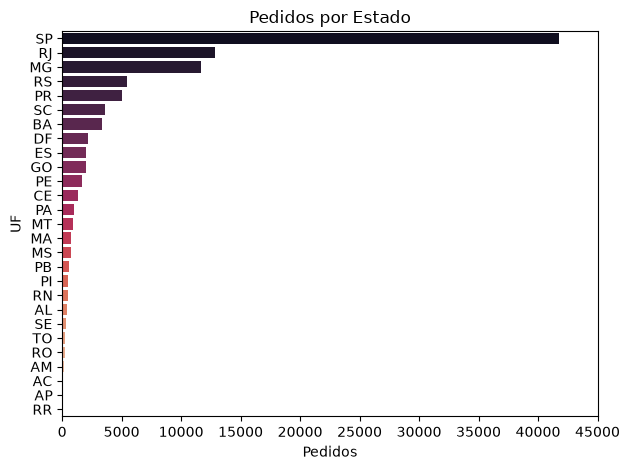

In [34]:
sns.barplot(
    data=pedidos_por_estado,
    y='customer_state',
    x='pedidos',
    palette='rocket',
    hue='customer_state'
)

plt.title('Pedidos por Estado')
plt.ylabel('UF')
plt.xlabel('Pedidos')
plt.xticks(np.arange(0, 50000, 5000))
plt.tight_layout()
plt.show()

## 4. Qual categoria de produto é mais vendida?

Contagem de itens vendidos por categoria. Cada linha de `f_order_items` representa
um item — a contagem por categoria reflete o volume real de produtos vendidos.
Os nomes das categorias são recuperados via join com `d_category`.

In [35]:
f_items_categoria = f_order_items.merge(d_category, on='category_id', how='left')

In [36]:
categoria_mais_vendida = calcular_contagem_agrupada(
    f_items_categoria, 'product_category_name', 'order_id', 'quantidade_vendida', 1
)
print(f"Categoria mais vendida: {categoria_mais_vendida.iloc[0]['product_category_name']} "
      f"({categoria_mais_vendida.iloc[0]['quantidade_vendida']:,} itens)")

Categoria mais vendida: cama_mesa_banho (11,115 itens)


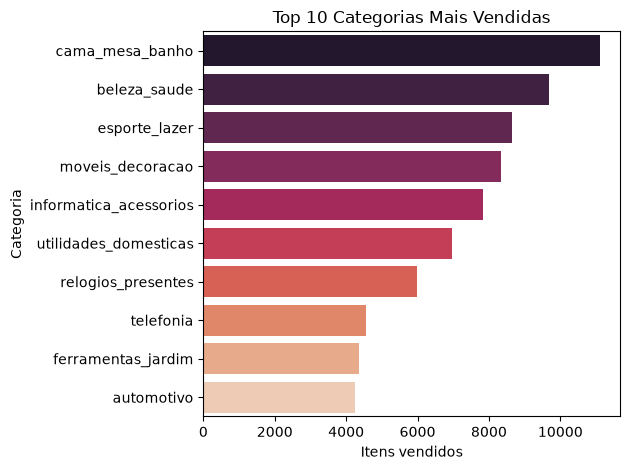

In [37]:
top10_categorias = calcular_contagem_agrupada(
    f_items_categoria, 'product_category_name', 'order_id', 'quantidade_vendida', 10
)

sns.barplot(
    data=top10_categorias,
    y='product_category_name',
    x='quantidade_vendida',
    palette='rocket',
    hue='product_category_name'
)

plt.title('Top 10 Categorias Mais Vendidas')
plt.ylabel('Categoria')
plt.xlabel('Itens vendidos')
plt.tight_layout()
plt.show()

## 5. Qual período do ano tem mais pedidos?

Análise de sazonalidade por mês. `order_purchase_timestamp` é extraído de `f_payments`
que contém a data de cada transação.

In [38]:
f_payments_data = f_payments.copy()
f_payments_data['order_month'] = f_payments_data['order_purchase_timestamp'].dt.month
f_payments_data['order_year']  = f_payments_data['order_purchase_timestamp'].dt.year

# Deduplica por order_id para não contar múltiplos pagamentos do mesmo pedido
pedidos_unicos_data = f_payments_data.drop_duplicates(subset='order_id')

mes_mais_vendas = calcular_contagem_agrupada(pedidos_unicos_data, 'order_month', 'order_id', 'pedidos', 1)
print(f"Mês com mais pedidos: {mes_mais_vendas.iloc[0]['order_month']} "
      f"({mes_mais_vendas.iloc[0]['pedidos']:,} pedidos)")

Mês com mais pedidos: 8 (10,843 pedidos)


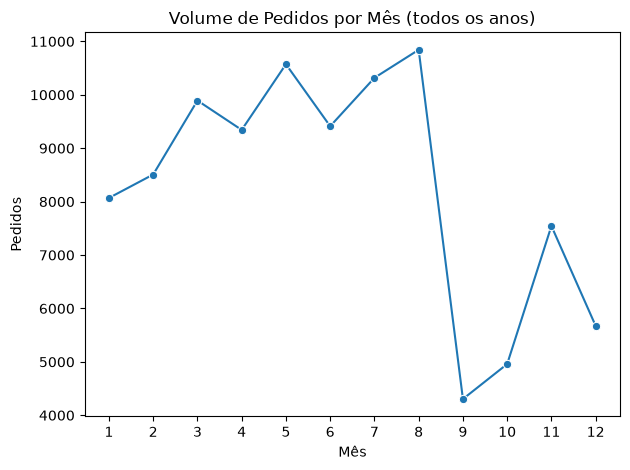

In [39]:
pedidos_por_mes = calcular_contagem_agrupada(
    pedidos_unicos_data, 'order_month', 'order_id', 'pedidos'
).sort_values('order_month')

sns.lineplot(data=pedidos_por_mes, x='order_month', y='pedidos', marker='o')

plt.title('Volume de Pedidos por Mês (todos os anos)')
plt.xlabel('Mês')
plt.ylabel('Pedidos')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 6. Qual forma de pagamento é mais usada?

Contagem de transações por método de pagamento em `f_payments`.
Um pedido pode ter múltiplos métodos — cada transação é contada individualmente.

In [40]:

d_payment = pd.read_parquet('../data/processed/d_payment.parquet')

f_payments_tipo = f_payments.merge(d_payment, on='payment_id', how='left')

forma_pagamento = calcular_contagem_agrupada(
    f_payments_tipo, 'payment_type', 'payment_transaction_id', 'transacoes'
)
forma_pagamento

,payment_type,transacoes
1,credit_card,76795
0,boleto,19784
4,voucher,5775
2,debit_card,1529
3,not_defined,3


## 7. Qual é o ticket médio geral e por estado?

Ticket médio calculado como média de `payment_value` por pedido único.
Pedidos com múltiplos pagamentos têm o valor somado antes do cálculo da média
para não distorcer o resultado.

In [41]:
# Soma payment_value por order_id (pedidos com múltiplos pagamentos)
valor_por_pedido = f_payments.groupby('order_id')['payment_value'].sum().reset_index()

ticket_medio_geral = round(valor_por_pedido['payment_value'].mean(), 2)
print(f"Ticket médio geral: R$ {ticket_medio_geral:,.2f}")

Ticket médio geral: R$ 160.99


In [42]:
# Join com f_orders para trazer customer_state_id e depois com d_state
valor_por_pedido_estado = valor_por_pedido.merge(
    f_orders[['order_id', 'customer_state_id']], on='order_id', how='left'
).merge(
    d_state.rename(columns={'state_id': 'customer_state_id', 'customer_seller_state': 'customer_state'}),
    on='customer_state_id',
    how='left'
)

ticket_por_estado = calcular_media_agrupada(
    valor_por_pedido_estado, 'customer_state', 'payment_value', 'ticket_medio'
)
ticket_por_estado.style.format({'ticket_medio': '{:.2f}'}).hide(axis='index')

customer_state,ticket_medio
PB,264.08
AC,242.97
RO,240.58
AP,239.16
AL,234.77
PA,223.89
TO,219.59
PI,219.24
RR,218.80
SE,214.99


## 8. O tempo de entrega impacta a avaliação do cliente?

Análise de correlação entre `time_delivered` e `review_score` em `f_orders`.
Apenas pedidos entregues têm `time_delivered` preenchido — nulos são excluídos.

**Hipótese:** pedidos com prazo de entrega maior recebem avaliações menores.

In [43]:
df_entrega_avaliacao = f_orders.dropna(subset=['time_delivered', 'review_score']).copy()

df_entrega_avaliacao['review_score'] = df_entrega_avaliacao['review_score'].round(0).astype(int)

tempo_por_nota = calcular_media_agrupada(
    df_entrega_avaliacao, 'review_score', 'time_delivered', 'tempo_medio_dias'
).sort_values('review_score')

tempo_por_nota.style.hide(axis='index').format({'tempo_medio_dias': '{:.2f}'})

review_score,tempo_medio_dias
1,21.88
2,17.22
3,14.78
4,12.84
5,11.21


In [48]:
correlacao = df_entrega_avaliacao[['time_delivered', 'review_score']].corr().iloc[0, 1]
print(f'Correlação entre tempo de entrega e avaliação: {correlacao:.2f}')
print('Hipótese confirmada pelos dados.')

Correlação entre tempo de entrega e avaliação: -0.33
Hipótese confirmada pelos dados.


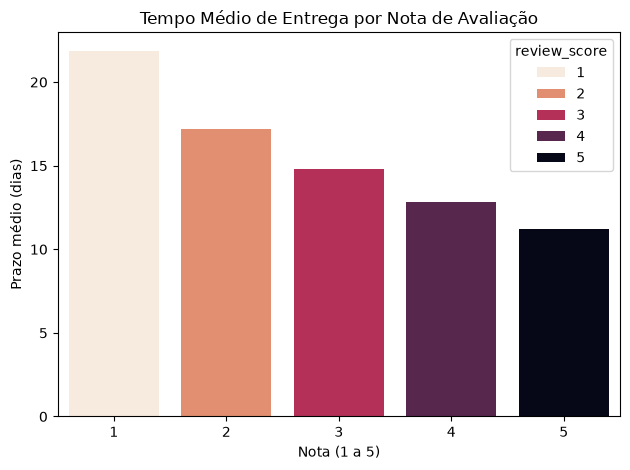

In [49]:
sns.barplot(
    data=tempo_por_nota,
    x='review_score',
    y='tempo_medio_dias',
    palette='rocket_r',
    hue='review_score'
)

plt.title('Tempo Médio de Entrega por Nota de Avaliação')
plt.xlabel('Nota (1 a 5)')
plt.ylabel('Prazo médio (dias)')
plt.tight_layout()
plt.show()

## Resumo dos Insights

| Pergunta | Insight |
|----------|---------|
| Estado com mais pedidos | SP concentra o maior volume, mas não lidera em ticket médio |
| Categoria mais vendida | cama_mesa_banho com 11.115 itens vendidos |
| Período com mais pedidos | Agosto apresenta o pico de volume no período analisado |
| Forma de pagamento | Cartão de crédito é o método dominante |
| Ticket médio | Estados com menor volume tendem a ter ticket médio maior |
| Entrega vs avaliação | Correlação negativa confirmada (-0.33) — maior prazo gera menor nota |